## The design from S.A.

|material | width |
|:----:|:----:|
|Quartz | 3mm |
|HfO2 | 25.71nm |
|Ag-Ge | 11.74nm |
|SiO2 | 107.1nm |
|HfO2 | 14.59nm |
|Ag-Ge | 11.91nm |
|SiO2 | 130.66nm |
|Al2O3 | 9.74nm |
|HfO2  | 78.12nm |
|Al2O3 | 125.49nm |
|HfO2 | 58.13nm |
|Al2O3 | 64.22nm |

In [ ]:
'''
import torch
# 使用複數張量進行計算，測試exp指數部分可以多大
complex_input = torch.tensor(325.960693359375 + 246.15028381347656j, dtype=torch.complex128)
result = torch.exp(-1j * complex_input)
print(result)
'''

tensor(5.7531e+106+5.5224e+106j, dtype=torch.complex128)


In [ ]:
'''
import torch
print(torch.cuda.is_available())  # 如果顯示 True，表示 GPU 可用
print(torch.cuda.get_device_name(0))  # 顯示 GPU 型號
'''

True
NVIDIA GeForce RTX 3050 Laptop GPU


## Generate dataset

### necessary functions

In [ ]:
from csv import DictReader
import numpy as np

wl_ag = []
n_ag = []
k_ag = []
with open('Ag.txt', 'r') as csv_file:
    reader = DictReader(csv_file, delimiter='\t', fieldnames=['wavelength', 'n', 'k'])
    for i, line in enumerate(reader):
        if i != 0:
            wl_ag.append(float(line['wavelength']))
            n_ag.append(float(line['n']))
            k_ag.append(float(line['k']))
wl_ag = np.array(wl_ag)
n_ag = np.array(n_ag)
k_ag = np.array(k_ag)

In [ ]:
def n_al2o3(wl):#n = sqrt(1+X), wl:wavelength, ref:https://reurl.cc/g65Nqp, Sellmeier Eq
    nsq = 1 + 1.4313493*wl**2/(wl**2-0.0726631**2) + 0.65054713*wl**2/(wl**2-0.1193242**2) + 5.3414021*wl**2/(wl**2-18.028251**2)
    return np.sqrt(nsq)
def n_sio2(wl):
    nsq = 1 + 0.6961663*wl**2/(wl**2-0.0684043**2) + 0.4079426*wl**2/(wl**2-0.1162414**2) + 0.8974794*wl**2/(wl**2-9.896161**2)
    return np.sqrt(nsq)
def n_hfo2(wl):
    return 1.875 + 6.28e-3/(wl**2) + 5.8e-4/(wl**4)

In [ ]:
def Tr_M(nl, dl, k): #nl is index array, dl is thickness array, k is the wave vector of incoming wave.
    #normal incidence
    TI = np.array([[(nl[0]+1)/(2*nl[0]), (nl[0]-1)/(2*nl[0])], [(nl[0]-1)/(2*nl[0]), (nl[0]+1)/(2*nl[0])]])
    TD = np.array([[np.exp(1j*nl[0]*k*dl[0]),0],[0,np.exp(-1j*nl[0]*k*dl[0])]])
    TM = TD @ TI#total matrix for air to the first layer TD*TI
    for i, n in enumerate(nl):
        if (i+1) < len(nl):
            n1 = n
            n2 = nl[i+1]
            d = dl[i+1]
            TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
            TD = np.array([[np.exp(1j*n2*k*d),0],[0,np.exp(-1j*n2*k*d)]])
            TM = (TD @ TI) @ TM
    n1 = nl[-1]
    n2 = 1
    TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
    TM = TI @ TM
    return -TM[1,0]/TM[1,1], TM[0,0] - TM[0,1]*TM[1,0]/TM[1,1]#r, t

### main

In [ ]:
import random#會覆蓋原來檔案!!
from tqdm import tqdm  # 引入 tqdm
import numpy as np
from collections import defaultdict

# Assume you have a GPU-compatible version of Tr_M
# This function should accept two lists: refractive indices `nl` and thicknesses `dl`
# Replace the mock-up with your actual GPU-accelerated function using PyTorch

# Set device to GPU if available
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Material database with corresponding refractive indices
material_data = {
    "a": 4,  # Example refractive index for Ag
    "l": 3,  # Example refractive index for Al2O3
    "h": 2,  # Example refractive index for HfO2
    "s": 1   # Example refractive index for SiO2
}
# 初始化層數頻率統計
layer_count_frequency = defaultdict(int)
# Material options
materials = list(material_data.keys())

# Parameters
num_samples = 1000000
min_layers = 4
max_layers = 16

# Define layer thickness ranges
thickness_ranges = {
    "a": (10.0, 20.0, 0.1),       # min, max, step for Ag a 4
    "l": (10.0, 120.0, 0.1),    # min, max, step for Al2O3 l 3
    "h": (10.0, 120.0, 0.1),     # min, max, step for HfO2 h 2
    "s": (10.0, 120.0, 0.1)      # min, max, step for SiO2 s 1
}

# Helper function to sample thickness
def sample_thickness(material):
    min_thick, max_thick, step = thickness_ranges[material]
    return round(random.uniform(min_thick, max_thick) / step) * step

# Generate data
with open('trainmmm6.txt', 'w') as file:
    for _ in tqdm(range(num_samples), desc="Generating data"):
        # Randomly determine the number of layers
        num_layers = random.choices(range(min_layers, max_layers + 1),
                                    weights=[2**i for i in range(min_layers, max_layers + 1)],
                                    k=1)[0]

        # Generate layer structure ensuring no consecutive layers have the same material
        structure = []
        nl = []
        dl = []
        prev_material = None
        total_thickness = 0.0

        for _ in range(num_layers):
            material = random.choice([m for m in materials if m != prev_material])
            thickness_nm = sample_thickness(material)
            # 確保加入該層後總厚度不超過 800
            if total_thickness + thickness_nm  > 800:
                break
            thickness_um = thickness_nm / 1000.0  # Convert to µm
            structure.append(f"{material}_{thickness_nm:.1f}")
            nl.append(material_data[material])
            dl.append(thickness_um)
            total_thickness += thickness_nm
            prev_material = material

        # Convert nl and dl to PyTorch tensors and move to GPU
        #nl_tensor = torch.tensor(nl, device=device, dtype=torch.complex128)
        #dl_tensor = torch.tensor(dl, device=device, dtype=torch.float32)

        # Calculate transmission coefficients on GPU
        # 更新層數頻率統計
        layer_count_frequency[len(structure)] += 1
        Tcl = []
        wll = wl_ag / 1000  # Convert to µm and move to GPU

        for i, wl in enumerate(wll):
            nll = []
            for j in range(len(nl)):
                if nl[j] == 3:
                    nll.append(n_al2o3(wl))
                elif nl[j] == 2:
                    nll.append(n_hfo2(wl))
                elif nl[j] == 1:
                    nll.append(n_sio2(wl))
                elif nl[j] == 4:
                    nll.append(n_ag[i]+1j*k_ag[i])
            r, t = Tr_M(nll, dl, 2 * np.pi / wl)
            T = np.round(np.abs(t)**2 * 10000) / 10000  # Round to 4 decimal places
            Tcl.append(T)  # Move data back to CPU for saving and convert to scalar

        # Prepare structure and T string
        structure_str = ','.join(structure)
        Tcl_str = ','.join([f"{val:.3f}" for val in Tcl])

        # Write to file
        file.write(f"{structure_str}\n{Tcl_str}\n")

print("Data generation complete. Saved to 'data.txt'.")
# 結束後顯示最終統計結果
print("Final layer count frequency distribution:")
sorted_frequencies = sorted(layer_count_frequency.items())
for layers, freq in sorted_frequencies:
    print(f"{layers} layers: {freq} occurrences")





Generating data: 100%|██████████| 1000000/1000000 [4:59:19<00:00, 55.68it/s]

Data generation complete. Saved to 'data.txt'.

Final layer count frequency distribution:

4 layers: 118 occurrences

5 layers: 280 occurrences

6 layers: 472 occurrences

7 layers: 1004 occurrences

8 layers: 2428 occurrences

9 layers: 7705 occurrences

10 layers: 23587 occurrences

11 layers: 58382 occurrences

12 layers: 112070 occurrences

13 layers: 170251 occurrences

14 layers: 211522 occurrences

15 layers: 220054 occurrences

16 layers: 192127 occurrences


### pie chart

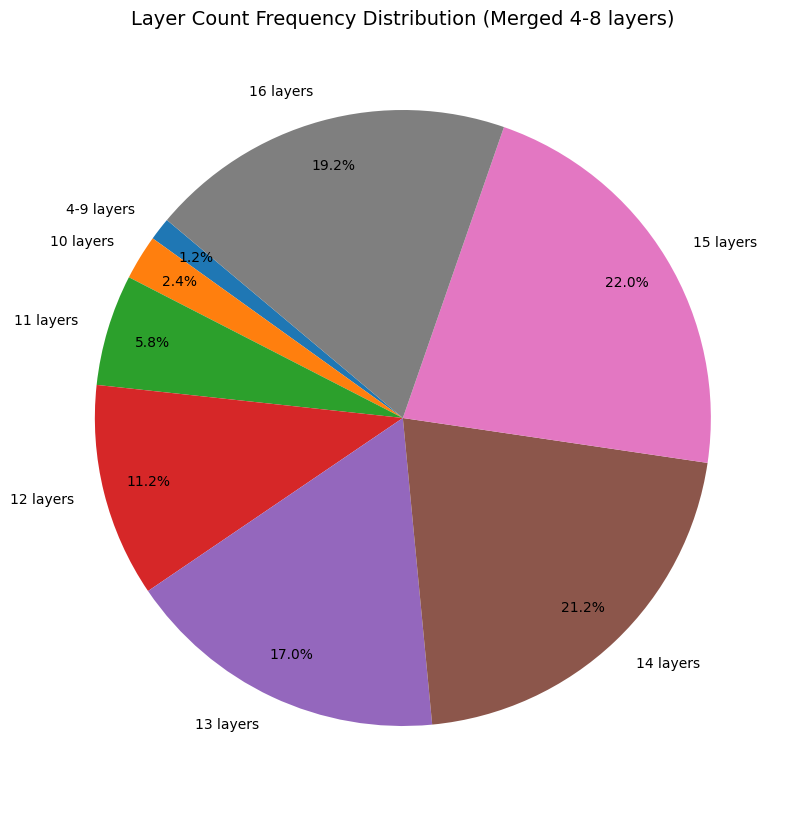

In [4]:
import matplotlib.pyplot as plt

# 層數與對應的頻率數據
layers = list(range(4, 17))
frequencies = [118, 280, 472, 1004, 2428, 7705, 23587, 58382, 112070, 170251, 211522, 220054, 192127]

merged_frequencies = [sum(frequencies[:6])] + frequencies[6:]
merged_labels = ["4-9 layers"] + [f"{layer} layers" for layer in layers[6:]]

# 繪製圓餅圖
plt.figure(figsize=(10, 10))
wedges, texts, autotexts = plt.pie(
    merged_frequencies, labels=merged_labels, autopct='%1.1f%%',
    startangle=140, pctdistance=0.85, textprops={'fontsize': 10}
)

# 調整標籤位置，防止重疊
for text in texts:
    text.set_fontsize(10)
    text.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.6))

plt.title("Layer Count Frequency Distribution (Merged 4-8 layers)", fontsize=14)
plt.show()

## Show the reconstruction(hypothesis) spectrum and reference spectrum

### necessary functions

In [ ]:
from csv import DictReader
import numpy as np

wl_ag = []
n_ag = []
k_ag = []
with open('Ag.txt', 'r') as csv_file:
    reader = DictReader(csv_file, delimiter='\t', fieldnames=['wavelength', 'n', 'k'])
    for i, line in enumerate(reader):
        if i != 0:
            wl_ag.append(float(line['wavelength']))
            n_ag.append(float(line['n']))
            k_ag.append(float(line['k']))
wl_ag = np.array(wl_ag)
n_ag = np.array(n_ag)
k_ag = np.array(k_ag)

def n_al2o3(wl):#n = sqrt(1+X), wl:wavelength, ref:https://reurl.cc/g65Nqp, Sellmeier Eq
    nsq = 1 + 1.4313493*wl**2/(wl**2-0.0726631**2) + 0.65054713*wl**2/(wl**2-0.1193242**2) + 5.3414021*wl**2/(wl**2-18.028251**2)
    return np.sqrt(nsq)
def n_sio2(wl):
    nsq = 1 + 0.6961663*wl**2/(wl**2-0.0684043**2) + 0.4079426*wl**2/(wl**2-0.1162414**2) + 0.8974794*wl**2/(wl**2-9.896161**2)
    return np.sqrt(nsq)
def n_hfo2(wl):
    return 1.875 + 6.28e-3/(wl**2) + 5.8e-4/(wl**4)

def Tr_M(nl, dl, k): #nl is index array, dl is thickness array, k is the wave vector of incoming wave.
    #normal incidence
    TI = np.array([[(nl[0]+1)/(2*nl[0]), (nl[0]-1)/(2*nl[0])], [(nl[0]-1)/(2*nl[0]), (nl[0]+1)/(2*nl[0])]])
    TD = np.array([[np.exp(1j*nl[0]*k*dl[0]),0],[0,np.exp(-1j*nl[0]*k*dl[0])]])
    TM = TD @ TI#total matrix for air to the first layer TD*TI
    for i, n in enumerate(nl):
        if (i+1) < len(nl):
            n1 = n
            n2 = nl[i+1]
            d = dl[i+1]
            TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
            TD = np.array([[np.exp(1j*n2*k*d),0],[0,np.exp(-1j*n2*k*d)]])
            TM = (TD @ TI) @ TM
    n1 = nl[-1]
    n2 = 1
    TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
    TM = TI @ TM
    return -TM[1,0]/TM[1,1], TM[0,0] - TM[0,1]*TM[1,0]/TM[1,1]#r, t

### test obtain d and nl from data_str

In [ ]:
import re

# 原始字串
data_str = "a_12.3,h_20.2,l_34.5,s_23.3"

# 提取浮點數列表 d
d = [float(x)/1000 for x in re.findall(r"\d+\.\d+", data_str)]

# 定義字母對應到數字的映射
mapping = {'a': 4, 'h': 2, 'l': 3, 's': 1}

# 提取標籤並映射到對應的數字 nl
labels = [x.split('_')[0] for x in data_str.split(',')]
nl = [mapping[label] for label in labels]

# 顯示結果
print("d =", d)   # [12.3, 20.2, 34.5, 23.3]
print("nl =", nl) # [4, 2, 3, 1]


d = [0.0123, 0.0202, 0.0345, 0.0233]
nl = [4, 2, 3, 1]


### get nd func, get T func.

In [ ]:
import re
import numpy as np

def get_nd(data):
    # 原始字串
    data_str = data  # "a_12.3,h_20.2,l_34.5,s_23.3"

    # 提取浮點數列表 d(um)
    d = [float(x)/1000 for x in re.findall(r"\d+\.\d+", data_str)]
    # 定義字母對應到數字的映射
    mapping = {'a': 4, 'h': 2, 'l': 3, 's': 1}

    # 提取標籤並映射到對應的數字 nl
    labels = [x.split('_')[0] for x in data_str.split(',')]
    nl = [mapping[label] for label in labels]

    # 顯示結果
    #print("d =", d)   # [12.3, 20.2, 34.5, 23.3]
    #print("nl =", nl) # [4, 2, 3, 1]
    return nl, d

def get_T(nl, dl):
    # Calculate transmission coefficients on GPU
    Tcl = []
    wll = wl_ag / 1000  # from Ag.txt

    for i, wl in enumerate(wll):
        nll = []
        for j in range(len(nl)):#get n(lambda) for each layer
            if nl[j] == 3:
                nll.append(n_al2o3(wl))
            elif nl[j] == 2:
                nll.append(n_hfo2(wl))
            elif nl[j] == 1:
                nll.append(n_sio2(wl))
            elif nl[j] == 4:
                nll.append(n_ag[i]+1j*k_ag[i])
        r, t = Tr_M(nll, dl, 2 * np.pi / wl)#coffs
        T = np.round(np.abs(t)**2 * 1000) / 1000  # Round to 3 decimal places
        Tcl.append(T)  # Move data back to CPU for saving and convert to scalar
    return Tcl


### plot the spectrums

In [ ]:
import matplotlib.pyplot as plt

def show_spec(hyp, ref):
    nlh, dlh = get_nd(hyp)
    nlr, dlr = get_nd(ref)
    Th = get_T(nlh, dlh)
    Tr = get_T(nlr, dlr)
    plt.xlim(0.25,2)
    plt.ylim(0,1)
    plt.plot(wll, Th, label = 'T_hyp')
    plt.plot(wll, Tr, label = 'T_ref')
    # Highlighting regions with background color
    plt.axvspan(0.4, 0.7, color='aqua', alpha=0.3)  # Visible region
    plt.axvspan(0.7, 2, color='pink', alpha=0.3)    # Infrared region
    # Adding labels for regions
    plt.text(0.55, 0.5, "Visible\nregion", color="orange", fontsize=12, ha='center')
    plt.text(1.35, 0.5, "Infrared\nregion", color="orange", fontsize=12, ha='center')

    plt.xlabel("wavelength($\mu$m)")
    plt.ylabel("Transmittance")
    plt.title("Spectrum Reconstruction of the Example Validation Sample")
    plt.legend()
    mse = np.mean((np.array(Tr) - np.array(Th)) ** 2)

    # 顯示結果
    print(f"MSE: {mse:.4f}")

### main

MSE: 0.0058


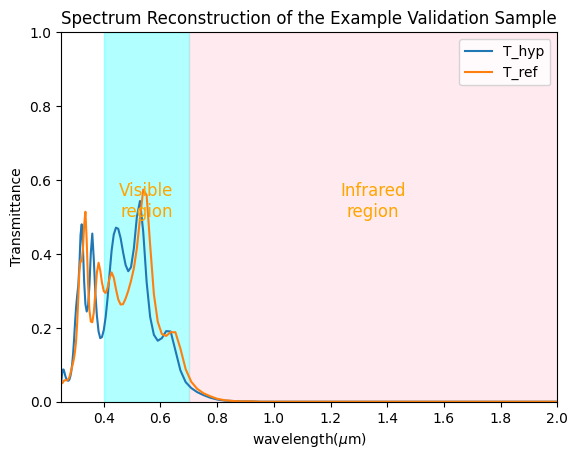

In [ ]:
hyp = "h_64.9,l_107.1,a_11.9,h_91.0,a_19.9,l_57.1,a_11.0,l_72.0,a_15.8,h_26.7,s_22.1,l_48.9,s_84.6,h_108.4"
ref = "l_43.1,h_116.4,a_13.4,s_85.8,a_17.2,h_27.3,s_91.9,a_14.8,h_97.8,a_12.4,l_83.7,h_97.3,l_56.5,h_28.0"
show_spec(hyp, ref)


## Generate ideal tgts

### necessary functions

In [ ]:
from csv import DictReader
import numpy as np

wl_ag = []
n_ag = []
k_ag = []
with open('Ag.txt', 'r') as csv_file:
    reader = DictReader(csv_file, delimiter='\t', fieldnames=['wavelength', 'n', 'k'])
    for i, line in enumerate(reader):
        if i != 0:
            wl_ag.append(float(line['wavelength']))
            n_ag.append(float(line['n']))
            k_ag.append(float(line['k']))
wl_ag = np.array(wl_ag)
n_ag = np.array(n_ag)
k_ag = np.array(k_ag)
wll = wl_ag/1000

def n_al2o3(wl):#n = sqrt(1+X), wl:wavelength, ref:https://reurl.cc/g65Nqp, Sellmeier Eq
    nsq = 1 + 1.4313493*wl**2/(wl**2-0.0726631**2) + 0.65054713*wl**2/(wl**2-0.1193242**2) + 5.3414021*wl**2/(wl**2-18.028251**2)
    return np.sqrt(nsq)
def n_sio2(wl):
    nsq = 1 + 0.6961663*wl**2/(wl**2-0.0684043**2) + 0.4079426*wl**2/(wl**2-0.1162414**2) + 0.8974794*wl**2/(wl**2-9.896161**2)
    return np.sqrt(nsq)
def n_hfo2(wl):
    return 1.875 + 6.28e-3/(wl**2) + 5.8e-4/(wl**4)

def Tr_M(nl, dl, k): #nl is index array, dl is thickness array, k is the wave vector of incoming wave.
    #normal incidence
    TI = np.array([[(nl[0]+1)/(2*nl[0]), (nl[0]-1)/(2*nl[0])], [(nl[0]-1)/(2*nl[0]), (nl[0]+1)/(2*nl[0])]])
    TD = np.array([[np.exp(1j*nl[0]*k*dl[0]),0],[0,np.exp(-1j*nl[0]*k*dl[0])]])
    TM = TD @ TI#total matrix for air to the first layer TD*TI
    for i, n in enumerate(nl):
        if (i+1) < len(nl):
            n1 = n
            n2 = nl[i+1]
            d = dl[i+1]
            TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
            TD = np.array([[np.exp(1j*n2*k*d),0],[0,np.exp(-1j*n2*k*d)]])
            TM = (TD @ TI) @ TM
    n1 = nl[-1]
    n2 = 1
    TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
    TM = TI @ TM
    return -TM[1,0]/TM[1,1], TM[0,0] - TM[0,1]*TM[1,0]/TM[1,1]#r, t

### generate ideal func.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_decay(wavelengths, center, sigma, peak_value):
    """
    使用高斯函数在指定中心和宽度范围内生成平滑的衰减。
    :param wavelengths: 波长列表
    :param center: 高斯分布中心
    :param sigma: 高斯分布宽度
    :param peak_value: 高斯分布峰值
    :return: 高斯衰减的值列表
    """
    return [peak_value * np.exp(-((wavelength - center) ** 2) / (2 * sigma ** 2)) for wavelength in wavelengths]

def generate_ideal(wavelengths, center, fwhm, amplitude=1):
    """
    生成高斯函数。
    :param wavelengths: 波长列表
    :param center: 高斯函数中心位置
    :param fwhm: 半高宽
    :param amplitude: 高斯函数的最大值（幅度）
    :return: 高斯函数值列表
    """
    # 计算标准差
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))

    # 计算高斯值
    return [
        amplitude * np.exp(-((wavelength - center) ** 2) / (2 * sigma ** 2))
        for wavelength in wavelengths
    ]


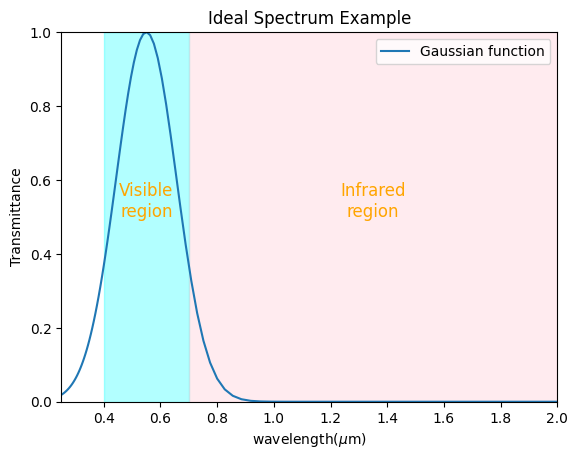

In [ ]:
#for taking a look at the generated spectrum
import matplotlib.pyplot as plt

Th = generate_ideal(wll, 0.55, 0.25, 1)
plt.xlim(0.25,2)
plt.ylim(0,1)
plt.plot(wll, Th, label = 'Gaussian function')
#plt.plot(wll, Tr, label = 'T_ref')
# Highlighting regions with background color
plt.axvspan(0.4, 0.7, color='aqua', alpha=0.3)  # Visible region
plt.axvspan(0.7, 2, color='pink', alpha=0.3)    # Infrared region
# Adding labels for regions
plt.text(0.55, 0.5, "Visible\nregion", color="orange", fontsize=12, ha='center')
plt.text(1.35, 0.5, "Infrared\nregion", color="orange", fontsize=12, ha='center')

plt.xlabel("wavelength($\mu$m)")
plt.ylabel("Transmittance")
plt.title("Ideal Spectrum Example")
plt.legend()

### target func.

In [ ]:
import torch
import math

def target_function(w_values, t_values):  # Loss = -FOM
    # 將 T 值和對應的 w 值轉換為 PyTorch 張量
    T_values = torch.tensor(t_values, dtype=torch.float32)
    w_values = torch.tensor(w_values, dtype=torch.float32)
    #print("w_values is: {}".format(w_values))
    #print("T_values is: {}".format(T_values))
    # 將波長轉換為角頻率 (rad/s)
    w_values = 6 * math.pi * 10**8 / w_values  # Convert to omega (rad/s)
    #print("w_values is: {}".format(w_values))
    # 篩選 w1 和 T1
    w1_mask = (w_values >= 2.69 * 10**9) & (w_values <= 4.96 * 10**9)
    w1 = w_values[w1_mask]
    T1 = T_values[w1_mask]

    # 篩選 w2 和 T2
    w2_mask = (w_values >= 9.42 * 10**8) & (w_values <= 9.42 * 10**9)
    w2 = w_values[w2_mask]
    T2 = T_values[w2_mask]
    #print("w1 is: {}".format(w1))
    #print("w2 is: {}".format(w2))
    #print("T1 is: {}".format(T1))
    #print("T2 is: {}".format(T2))
    # 計算積分
    I1 = torch.trapz(T1, w1)  # Numerator
    I2 = torch.trapz(T2, w2)  # Denominator
    #print("I1 is: {}".format(I1))
    #print("I2 is: {}".format(I2))
    # 計算 FOM 並返回負值作為損失
    FOM = I1 / I2
    #print("FOM is: {}".format(FOM.item()))

    return FOM  # Return negative FOM as the loss
    '''
    # 使用梯形法進行積分
    result = torch.trapz(T, w_values)
    print("離散 T 值的積分結果:", result)
    '''

### main

In [ ]:
import statistics
import numpy

#example
wll = wl_ag/1000
T_i = generate_ideal(wll, 0.55, random.uniform(0.15, 0.25), 1)
# 計算目標函數的值
t_values = torch.tensor(T_i)  # 將列表轉換為 PyTorch 張量
w_values = torch.tensor(wll, dtype=torch.float32)  # 波長值張量
fom = target_function(w_values, t_values)
print("FOM of the ideal spectrum: {}".format(fom.item()))
print(len(T_i))
# 將 T 轉為以逗號分隔的字串
T_i = ",".join(f"{value:.3f}" for value in T_i)
print(T_i)

foms = []
with open('idealmm6_3.txt', 'w') as file:
    datasize = 10000
    for i in range(datasize):
        T_i = generate_ideal(wll, 0.55, random.uniform(0.15, 0.25), 1)
        # 計算目標函數的值
        t_values = torch.tensor(T_i)  # 將列表轉換為 PyTorch 張量
        w_values = torch.tensor(wll, dtype=torch.float32)  # 波長值張量
        fom = target_function(w_values, t_values)
        foms.append(fom.item())
        T_i = ",".join(f"{value:.3f}" for value in T_i)
        # Write to file
        file.write(f"{T_i}\n")

# 計算平均值和標準差
mean = statistics.mean(foms)
stdev = statistics.stdev(foms)

print(f"fom平均值: {mean:.4f}")
print(f"fom標準差: {stdev:.4f}")


C:\Users\User\AppData\Local\Temp\ipykernel_18796\197236745.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  T_values = torch.tensor(t_values, dtype=torch.float32)
C:\Users\User\AppData\Local\Temp\ipykernel_18796\197236745.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w_values = torch.tensor(w_values, dtype=torch.float32)


FOM of the ideal spectrum: 0.911081075668335
121
0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.002,0.002,0.002,0.002,0.002,0.003,0.003,0.003,0.004,0.004,0.005,0.005,0.006,0.006,0.007,0.008,0.009,0.010,0.011,0.013,0.014,0.016,0.018,0.021,0.024,0.027,0.031,0.035,0.040,0.045,0.051,0.059,0.067,0.076,0.087,0.100,0.114,0.130,0.149,0.170,0.194,0.221,0.251,0.285,0.323,0.366,0.412,0.463,0.517,0.575,0.636,0.699,0.761,0.822,0.879,0.928,0.967,0.992,1.000,0.988,0.953,0.896,0.817,0.720,0.609,0.493,0.379,0.274,0.185,0.115,0.065,0.033,0.015,0.006,0.002,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
fom平均值: 0.9115
fom標準差: 0.0491


## Evaluate fom of the generated structures

### necessary functions


In [ ]:
from csv import DictReader
import numpy as np

wl_ag = []
n_ag = []
k_ag = []
with open('Ag.txt', 'r') as csv_file:
    reader = DictReader(csv_file, delimiter='\t', fieldnames=['wavelength', 'n', 'k'])
    for i, line in enumerate(reader):
        if i != 0:
            wl_ag.append(float(line['wavelength']))
            n_ag.append(float(line['n']))
            k_ag.append(float(line['k']))
wl_ag = np.array(wl_ag)
n_ag = np.array(n_ag)
k_ag = np.array(k_ag)
wll = wl_ag/1000

def n_al2o3(wl):#n = sqrt(1+X), wl:wavelength, ref:https://reurl.cc/g65Nqp, Sellmeier Eq
    nsq = 1 + 1.4313493*wl**2/(wl**2-0.0726631**2) + 0.65054713*wl**2/(wl**2-0.1193242**2) + 5.3414021*wl**2/(wl**2-18.028251**2)
    return np.sqrt(nsq)
def n_sio2(wl):
    nsq = 1 + 0.6961663*wl**2/(wl**2-0.0684043**2) + 0.4079426*wl**2/(wl**2-0.1162414**2) + 0.8974794*wl**2/(wl**2-9.896161**2)
    return np.sqrt(nsq)
def n_hfo2(wl):
    return 1.875 + 6.28e-3/(wl**2) + 5.8e-4/(wl**4)

def Tr_M(nl, dl, k): #nl is index array, dl is thickness array, k is the wave vector of incoming wave.
    #normal incidence
    TI = np.array([[(nl[0]+1)/(2*nl[0]), (nl[0]-1)/(2*nl[0])], [(nl[0]-1)/(2*nl[0]), (nl[0]+1)/(2*nl[0])]])
    TD = np.array([[np.exp(1j*nl[0]*k*dl[0]),0],[0,np.exp(-1j*nl[0]*k*dl[0])]])
    TM = TD @ TI#total matrix for air to the first layer TD*TI
    for i, n in enumerate(nl):
        if (i+1) < len(nl):
            n1 = n
            n2 = nl[i+1]
            d = dl[i+1]
            TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
            TD = np.array([[np.exp(1j*n2*k*d),0],[0,np.exp(-1j*n2*k*d)]])
            TM = (TD @ TI) @ TM
    n1 = nl[-1]
    n2 = 1
    TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
    TM = TI @ TM
    return -TM[1,0]/TM[1,1], TM[0,0] - TM[0,1]*TM[1,0]/TM[1,1]#r, t

In [ ]:
import re
import numpy as np

def get_nd(data):
    # 原始字串
    data_str = data  # "a_12.3,h_20.2,l_34.5,s_23.3"

    # 提取浮點數列表 d(um)
    d = [float(x)/1000 for x in re.findall(r"\d+\.\d+", data_str)]
    # 定義字母對應到數字的映射
    mapping = {'a': 4, 'h': 2, 'l': 3, 's': 1}

    # 提取標籤並映射到對應的數字 nl
    labels = [x.split('_')[0] for x in data_str.split(',')]
    nl = [mapping[label] for label in labels]

    # 顯示結果
    #print("d =", d)   # [12.3, 20.2, 34.5, 23.3]
    #print("nl =", nl) # [4, 2, 3, 1]
    return nl, d

def get_T(nl, dl):
    # Calculate transmission coefficients on GPU
    Tcl = []
    wll = wl_ag / 1000  # from Ag.txt

    for i, wl in enumerate(wll):
        nll = []
        for j in range(len(nl)):#get n(lambda) for each layer
            if nl[j] == 3:
                nll.append(n_al2o3(wl))
            elif nl[j] == 2:
                nll.append(n_hfo2(wl))
            elif nl[j] == 1:
                nll.append(n_sio2(wl))
            elif nl[j] == 4:
                nll.append(n_ag[i]+1j*k_ag[i])
        r, t = Tr_M(nll, dl, 2 * np.pi / wl)#coffs
        T = np.round(np.abs(t)**2 * 1000) / 1000  # Round to 3 decimal places
        Tcl.append(T)  # Move data back to CPU for saving and convert to scalar
    return Tcl


### 處理預測檔

In [ ]:
import re

# 定義正則表達式匹配格式
pattern = re.compile(r"^([ahsl]_\d{2,3}\.\d,)*[ahsl]_\d{2,3}\.\d$")

# 原始檔案名稱
infile = 'idealmm_3_prediction_6868.txt'
outfile = "idealmm_3_prediction_6868_md.txt"

# 讀取檔案
with open(infile, "r") as f:
    lines = f.readlines()

# 將符合格式的組 (h, s) 保留
filtered_lines = []
for i in range(0, len(lines), 2):  # 每兩行為一組
    h = lines[i].strip()  # 第一行是 h
    s = lines[i + 1].strip()  # 第二行是 s
    if pattern.match(h):  # 只檢查 h 是否符合格式
        filtered_lines.append(h + "\n")  # 保留 h
        filtered_lines.append(s + "\n")  # 保留對應的 s

# 覆寫檔案，僅寫入篩選後的內容
with open(outfile, "w") as f:
    f.writelines(filtered_lines)

print("不符合格式的數據組已刪除，符合格式的數據組已保留到文件中。")


不符合格式的數據組已刪除，符合格式的數據組已保留到文件中。


In [ ]:
import matplotlib.pyplot as plt
import torch
import math

def target_function(w_values, t_values):  # Loss = -FOM
    # 將 T 值和對應的 w 值轉換為 PyTorch 張量
    T_values = torch.tensor(t_values, dtype=torch.float32)
    w_values = torch.tensor(w_values, dtype=torch.float32)
    #print("w_values is: {}".format(w_values))
    #print("T_values is: {}".format(T_values))
    # 將波長轉換為角頻率 (rad/s)
    w_values = 6 * math.pi * 10**8 / w_values  # Convert to omega (rad/s)
    #print("w_values is: {}".format(w_values))
    # 篩選 w1 和 T1
    w1_mask = (w_values >= 2.69 * 10**9) & (w_values <= 4.96 * 10**9)
    w1 = w_values[w1_mask]
    T1 = T_values[w1_mask]

    # 篩選 w2 和 T2
    w2_mask = (w_values >= 9.42 * 10**8) & (w_values <= 9.42 * 10**9)
    w2 = w_values[w2_mask]
    T2 = T_values[w2_mask]
    #print("w1 is: {}".format(w1))
    #print("w2 is: {}".format(w2))
    #print("T1 is: {}".format(T1))
    #print("T2 is: {}".format(T2))
    # 計算積分
    I1 = torch.trapz(T1, w1)  # Numerator
    I2 = torch.trapz(T2, w2)  # Denominator
    #print("I1 is: {}".format(I1))
    #print("I2 is: {}".format(I2))
    # 計算 FOM 並返回負值作為損失
    FOM = I1 / I2
    #print("FOM is: {}".format(FOM.item()))

    return FOM  # Return negative FOM as the loss
    '''
    # 使用梯形法進行積分
    result = torch.trapz(T, w_values)
    print("離散 T 值的積分結果:", result)
    '''

def show_spec_i(hyp, Tr):
    nlh, dlh = get_nd(hyp)
    #nlr, dlr = get_nd(ref)
    Th = get_T(nlh, dlh)
    #Tr = get_T(nlr, dlr)
    plt.xlim(0.25,2)
    plt.ylim(0,1)
    plt.plot(wll, Th, label = 'T_Transformer')
    #plt.plot(wll, Tr, label = 'T_ref')
    nl = [2,4,1,2,4,1,3,2,3,2,3]
    dl = [0.02571,0.01174,0.1071,0.01459,0.01191,0.13066,0.00974,0.07812,0.12549,0.05813,0.06422]
    Ta = get_T(nl, dl)
    plt.plot(wll, Ta, label = 'T_S.A.')
    # Highlighting regions with background color
    plt.axvspan(0.4, 0.7, color='aqua', alpha=0.3)  # Visible region
    plt.axvspan(0.7, 2, color='pink', alpha=0.3)    # Infrared region
    # Adding labels for regions
    plt.text(0.55, 0.5, "Visible\nregion", color="orange", fontsize=12, ha='center')
    plt.text(1.35, 0.5, "Infrared\nregion", color="orange", fontsize=12, ha='center')

    plt.xlabel("wavelength($\mu$m)")
    plt.ylabel("Transmittance")
    plt.title("Transmittance of the design")
    plt.legend()
    #mse = np.mean((np.array(Tr) - np.array(Th)) ** 2)
    fom = target_function(wll, Th)

    # 顯示結果
    #print(f"MSE: {mse:.4f}")
    print(f"Design FOM: {fom:.4f}")
    fom = target_function(wll, Ta)
    print(f"S.A. FOM: {fom:.4f}")

def cal_i(hyp, Tr):
    nlh, dlh = get_nd(hyp)
    #nlr, dlr = get_nd(ref)
    Th = get_T(nlh, dlh)
    # 計算目標函數的值
    t_values = torch.tensor(Th)  # 將列表轉換為 PyTorch 張量
    w_values = torch.tensor(wll, dtype=torch.float32)  # 波長值張量
    fom = target_function(w_values, t_values)
    mse = np.mean((np.array(Tr) - np.array(Th)) ** 2)

    return mse, fom.item()

def replace_materials(input_str):
    # 定义替换规则
    replacements = {
        'h': 'HfO2',
        'a': 'Ag',
        'l': 'Al2O3',  # 如果需要处理 'l'，可以保留这条
        's': 'SiO2'
    }

    # 逐个替换
    for old, new in replacements.items():
        input_str = input_str.replace(old + '_', new + '_')

    return input_str

def show_spec_re(hyp, Tr):
    nlh, dlh = get_nd(hyp)
    #nlr, dlr = get_nd(ref)
    Th = get_T(nlh, dlh)
    #Tr = get_T(nlr, dlr)
    plt.xlim(0.25,2)
    plt.ylim(0,1)
    plt.plot(wll, Th, label = 'T_hyp')
    plt.plot(wll, Tr, label = 'T_ref')
    # Highlighting regions with background color
    plt.axvspan(0.4, 0.7, color='aqua', alpha=0.3)  # Visible region
    plt.axvspan(0.7, 2, color='pink', alpha=0.3)    # Infrared region
    # Adding labels for regions
    plt.text(0.55, 0.5, "Visible\nregion", color="orange", fontsize=12, ha='center')
    plt.text(1.35, 0.5, "Infrared\nregion", color="orange", fontsize=12, ha='center')

    plt.xlabel("wavelength($\mu$m)")
    plt.ylabel("Transmittance")
    plt.title("Spectrum Reconstruction of the Example Ideal Sample")
    plt.legend()
    mse = np.mean((np.array(Tr) - np.array(Th)) ** 2)
    fom = target_function(wll, Th)

    # 顯示結果
    print(f"MSE: {mse:.4f}")
    print(f"FOM: {fom:.4f}")

### main

In [ ]:
from tqdm import tqdm
infile = 'idealmm_3_prediction_6868_md.txt'

# 讀取檔案
with open(infile, "r") as f:
    lines = f.readlines()

h = lines[0].strip()  # 第一行是 h
s = lines[1].strip()  # 第二行是 s

print(h)
print(s)
decimal_list = list(map(float, s.split(",")))

print(decimal_list)

# 將符合格式的組 (h, s) 保留
mses = []
foms = []
for i in tqdm(range(0, len(lines), 2), desc="Calculating prediction"):
    h = lines[i].strip()  # 第一行是 h
    s = lines[i + 1].strip()  # 第二行是 s
    s = list(map(float, s.split(",")))
    mse, fom = cal_i(h, s)
    foms.append(fom)
    mses.append(mse)



h_21.9,s_24.8,a_11.8,h_75.7,a_15.8,s_19.0,h_66.6,a_19.6,s_16.4,h_71.7,a_16.1,h_39.3,s_51.6,h_37.1,a_13.0,h_36.5
0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.003,0.003,0.003,0.003,0.003,0.004,0.004,0.004,0.005,0.005,0.006,0.006,0.007,0.007,0.008,0.008,0.009,0.010,0.011,0.012,0.013,0.015,0.016,0.018,0.019,0.021,0.024,0.026,0.029,0.032,0.036,0.039,0.044,0.049,0.054,0.060,0.067,0.075,0.084,0.093,0.104,0.117,0.130,0.146,0.163,0.182,0.203,0.227,0.254,0.283,0.315,0.351,0.389,0.431,0.477,0.525,0.576,0.630,0.685,0.741,0.796,0.849,0.898,0.940,0.972,0.993,1.000,0.990,0.961,0.912,0.845,0.760,0.661,0.554,0.444,0.339,0.244,0.164,0.102,0.058,0.030,0.014,0.005,0.002,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
[0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.003, 0.003, 

Calculating prediction:   0%|          | 0/9149 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_10228\717981988.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  T_values = torch.tensor(t_values, dtype=torch.float32)
C:\Users\User\AppData\Local\Temp\ipykernel_10228\717981988.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w_values = torch.tensor(w_values, dtype=torch.float32)
Calculating prediction: 100%|██████████| 9149/9149 [02:42<00:00, 56.20it/s]


### 計算fom並找出fom最大的結構

最大值: 0.9722508192062378
最小值: 0.762962818145752
平均值: 0.8822296325177205
標準差: 0.047688541366570567
最佳結構: HfO2_41.5,Ag_19.9,HfO2_79.6,Ag_19.9,SiO2_28.0,HfO2_26.7,SiO2_39.5,Ag_19.9,SiO2_112.8,Ag_19.9,SiO2_112.8,Ag_19.6,SiO2_118.2,Ag_14.7,SiO2_25.7,HfO2_23.7
Design FOM: 0.9723
S.A. FOM: 0.4939


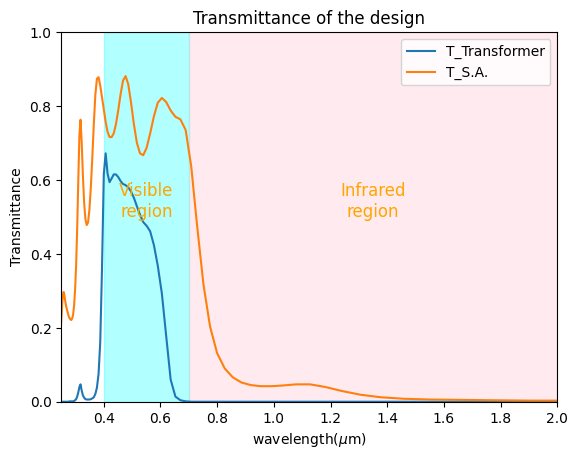

In [ ]:

import statistics

# 計算最大值和最小值（使用內建函數）
data = foms
max_value = max(data)
min_value = min(data)

# 計算平均值和標準差（使用 statistics 模組）
mean_value = statistics.mean(data)
stdev_value = statistics.stdev(data)

max_index = data.index(max_value)

# 輸出結果
print(f"最大值: {max_value}")
print(f"最小值: {min_value}")
print(f"平均值: {mean_value}")
print(f"標準差: {stdev_value}")
print(f"最佳結構: {replace_materials(lines[2*max_index].strip()) }")
h_best = lines[2*max_index].strip()
s_best = lines[2*max_index+1].strip()
s_best = list(map(float, s_best.split(",")))

show_spec_i(h_best, s_best)


### 計算mse並找出mse最小的結構

In [ ]:
# 計算最大值和最小值（使用內建函數）
data = mses
max_value = max(data)
min_value = min(data)

# 計算平均值和標準差（使用 statistics 模組）
mean_value = statistics.mean(data)
stdev_value = statistics.stdev(data)

max_index = data.index(max_value)

# 輸出結果
print(f"最大值: {max_value}")
print(f"最小值: {min_value}")
print(f"平均值: {mean_value}")
print(f"標準差: {stdev_value}")

最大值: 0.052010785123966945
最小值: 0.005663785123966942
平均值: 0.01641455783543159
標準差: 0.008995586048721678


data size: 9149 
[4180]
結構: h_35.5,a_12.8,h_71.7,a_13.9,s_16.4,h_67.1,a_19.9,l_102.6,a_14.2,s_16.4,h_34.5
max index: 4180
mse: 0.005663785123966942
Design FOM: 0.8116
S.A. FOM: 0.4939


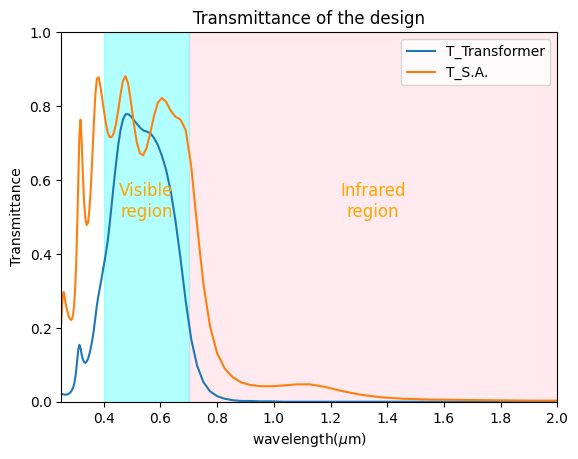

In [ ]:
data = mses
print("data size: {} ".format(len(data)))
top_10_indices = sorted(range(len(data)), key=lambda i: data[i])[0:1]
print(top_10_indices)
#top_10_indices = sorted(range(len(data)), key=lambda i: data[i], reverse=True)[:-10]
#last_10_indices = sorted(range(len(data)), key=lambda i: data[i])[-10:]
for i in range(len(top_10_indices)):
    max_index = top_10_indices[i]
    print(f"結構: {lines[2*max_index].strip() }")
    print("max index: {}".format(max_index))
    print("mse: {}".format(mses[max_index]))
    h_best = lines[2*max_index].strip()
    s_best = lines[2*max_index+1].strip()
    s_best = list(map(float, s_best.split(",")))

    show_spec_i(h_best, s_best)

9149
最大值: 0.052010785123966945
最小值: 0.005663785123966942
平均值: 0.01641455783543159
標準差: 0.008995586048721678
最接近平均值的結構: HfO2_36.3,Ag_12.8,HfO2_70.3,Ag_13.6,SiO2_12.2,HfO2_64.4,Ag_19.6,SiO2_20.3,HfO2_64.4,Ag_19.9,SiO2_20.3,HfO2_71.7,Ag_15.8,HfO2_111.9,Ag_13.9,SiO2_20.3,HfO2_25.3
MSE: 0.0164
FOM: 0.9006


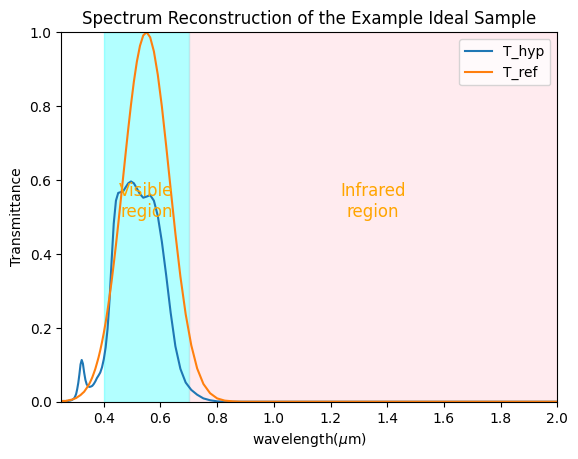

In [ ]:
import statistics

# 計算最大值和最小值（使用內建函數）
data = mses
max_value = max(data)
min_value = min(data)

# 計算平均值和標準差（使用 statistics 模組）
mean_value = statistics.mean(data)
stdev_value = statistics.stdev(data)

# 找到最接近平均值的索引
closest_index = min(range(len(data)), key=lambda i: abs(data[i] - mean_value))

# 輸出結果
print(len(data))
print(f"最大值: {max_value}")
print(f"最小值: {min_value}")
print(f"平均值: {mean_value}")
print(f"標準差: {stdev_value}")
print(f"最接近平均值的結構: {replace_materials(lines[2*closest_index].strip())}")
h_best = lines[2*closest_index].strip()
s_best = lines[2*closest_index + 1].strip()
s_best = list(map(float, s_best.split(",")))

show_spec_re(h_best, s_best)


# Plot loss

In [ ]:
import re
import matplotlib.pyplot as plt

# 讀取文件並提取數據
def extract_losses(file_path):
    epochs = []
    train_losses = []
    val_losses = []

    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            match = re.match(r'Epoch (\d+): average training loss = (\d+\.\d+), average validation loss = (\d+\.\d+)', line)
            if match:
                epoch = int(match.group(1))
                train_loss = float(match.group(2))
                val_loss = float(match.group(3))
                epochs.append(epoch)
                train_losses.append(train_loss)
                val_losses.append(val_loss)

    return epochs, train_losses, val_losses

# 繪製曲線圖
def plot_loss_curve(epochs, train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Training Loss', marker='o', linestyle='-', color='blue')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='o', linestyle='--', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss vs. Epoch')
    plt.legend()
    plt.grid(True)
    plt.show()




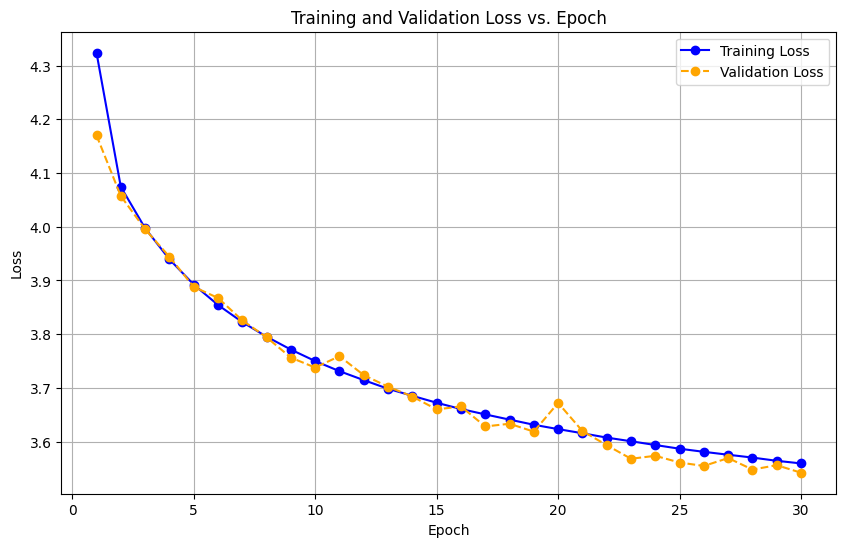

In [ ]:
# 主函數
file_path = '.\checkpoints\\transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024\\average traing loss and validation loss for every epoch.txt'
epochs, train_losses, val_losses = extract_losses(file_path)
plot_loss_curve(epochs, train_losses, val_losses)#"\checkpoints\transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024\average traing loss and validation loss for every epoch.txt"

# Plot mse

### necessary functions


In [ ]:
from csv import DictReader
import numpy as np

wl_ag = []
n_ag = []
k_ag = []
with open('Ag.txt', 'r') as csv_file:
    reader = DictReader(csv_file, delimiter='\t', fieldnames=['wavelength', 'n', 'k'])
    for i, line in enumerate(reader):
        if i != 0:
            wl_ag.append(float(line['wavelength']))
            n_ag.append(float(line['n']))
            k_ag.append(float(line['k']))
wl_ag = np.array(wl_ag)
n_ag = np.array(n_ag)
k_ag = np.array(k_ag)
wll = wl_ag/1000

def n_al2o3(wl):#n = sqrt(1+X), wl:wavelength, ref:https://reurl.cc/g65Nqp, Sellmeier Eq
    nsq = 1 + 1.4313493*wl**2/(wl**2-0.0726631**2) + 0.65054713*wl**2/(wl**2-0.1193242**2) + 5.3414021*wl**2/(wl**2-18.028251**2)
    return np.sqrt(nsq)
def n_sio2(wl):
    nsq = 1 + 0.6961663*wl**2/(wl**2-0.0684043**2) + 0.4079426*wl**2/(wl**2-0.1162414**2) + 0.8974794*wl**2/(wl**2-9.896161**2)
    return np.sqrt(nsq)
def n_hfo2(wl):
    return 1.875 + 6.28e-3/(wl**2) + 5.8e-4/(wl**4)

def Tr_M(nl, dl, k): #nl is index array, dl is thickness array, k is the wave vector of incoming wave.
    #normal incidence
    TI = np.array([[(nl[0]+1)/(2*nl[0]), (nl[0]-1)/(2*nl[0])], [(nl[0]-1)/(2*nl[0]), (nl[0]+1)/(2*nl[0])]])
    TD = np.array([[np.exp(1j*nl[0]*k*dl[0]),0],[0,np.exp(-1j*nl[0]*k*dl[0])]])
    TM = TD @ TI#total matrix for air to the first layer TD*TI
    for i, n in enumerate(nl):
        if (i+1) < len(nl):
            n1 = n
            n2 = nl[i+1]
            d = dl[i+1]
            TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
            TD = np.array([[np.exp(1j*n2*k*d),0],[0,np.exp(-1j*n2*k*d)]])
            TM = (TD @ TI) @ TM
    n1 = nl[-1]
    n2 = 1
    TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
    TM = TI @ TM
    return -TM[1,0]/TM[1,1], TM[0,0] - TM[0,1]*TM[1,0]/TM[1,1]#r, t

In [ ]:
import re
import numpy as np
import torch

def get_nd(data):
    # 原始字串
    data_str = data  # "a_12.3,h_20.2,l_34.5,s_23.3"

    # 提取浮點數列表 d(um)
    d = [float(x)/1000 for x in re.findall(r"\d+\.\d+", data_str)]
    # 定義字母對應到數字的映射
    mapping = {'a': 4, 'h': 2, 'l': 3, 's': 1}

    # 提取標籤並映射到對應的數字 nl
    labels = [x.split('_')[0] for x in data_str.split(',')]
    nl = [mapping[label] for label in labels]

    # 顯示結果
    #print("d =", d)   # [12.3, 20.2, 34.5, 23.3]
    #print("nl =", nl) # [4, 2, 3, 1]
    return nl, d

def get_T(nl, dl):
    # Calculate transmission coefficients on GPU
    Tcl = []
    wll = wl_ag / 1000  # from Ag.txt

    for i, wl in enumerate(wll):
        nll = []
        for j in range(len(nl)):#get n(lambda) for each layer
            if nl[j] == 3:
                nll.append(n_al2o3(wl))
            elif nl[j] == 2:
                nll.append(n_hfo2(wl))
            elif nl[j] == 1:
                nll.append(n_sio2(wl))
            elif nl[j] == 4:
                nll.append(n_ag[i]+1j*k_ag[i])
        r, t = Tr_M(nll, dl, 2 * np.pi / wl)#coffs
        T = np.round(np.abs(t)**2 * 1000) / 1000  # Round to 3 decimal places
        Tcl.append(T)  # Move data back to CPU for saving and convert to scalar
    return Tcl

# 提取 srcs 和 hyps
def extract_srcs_and_hyps(file_path):
    srcs = []
    hyps = []

    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            s, h = line.strip().split('\t')  # 以 tab 分割
            srcs.append(s)
            hyps.append(h)

    return srcs, hyps

import torch
import math

def target_function(w_values, t_values):  # Loss = -FOM
    # 將 T 值和對應的 w 值轉換為 PyTorch 張量
    T_values = torch.tensor(t_values, dtype=torch.float32)
    w_values = torch.tensor(w_values, dtype=torch.float32)
    #print("w_values is: {}".format(w_values))
    #print("T_values is: {}".format(T_values))
    # 將波長轉換為角頻率 (rad/s)
    w_values = 6 * math.pi * 10**8 / w_values  # Convert to omega (rad/s)
    #print("w_values is: {}".format(w_values))
    # 篩選 w1 和 T1
    w1_mask = (w_values >= 2.69 * 10**9) & (w_values <= 4.96 * 10**9)
    w1 = w_values[w1_mask]
    T1 = T_values[w1_mask]

    # 篩選 w2 和 T2
    w2_mask = (w_values >= 9.42 * 10**8) & (w_values <= 9.42 * 10**9)
    w2 = w_values[w2_mask]
    T2 = T_values[w2_mask]
    #print("w1 is: {}".format(w1))
    #print("w2 is: {}".format(w2))
    #print("T1 is: {}".format(T1))
    #print("T2 is: {}".format(T2))
    # 計算積分
    I1 = torch.trapz(T1, w1)  # Numerator
    I2 = torch.trapz(T2, w2)  # Denominator
    #print("I1 is: {}".format(I1))
    #print("I2 is: {}".format(I2))
    # 計算 FOM 並返回負值作為損失
    FOM = I1 / I2
    #print("FOM is: {}".format(FOM.item()))

    return FOM  # Return negative FOM as the loss
    '''
    # 使用梯形法進行積分
    result = torch.trapz(T, w_values)
    print("離散 T 值的積分結果:", result)
    '''

def cal_i(hyp, Tr):
    nlh, dlh = get_nd(hyp)
    #nlr, dlr = get_nd(ref)
    Th = get_T(nlh, dlh)
    # 計算目標函數的值
    t_values = torch.tensor(Th)  # 將列表轉換為 PyTorch 張量
    w_values = torch.tensor(wll, dtype=torch.float32)  # 波長值張量
    #fom = target_function(w_values, t_values)
    mse = np.mean((np.array(Tr) - np.array(Th)) ** 2)
    return mse

def show_spec_i(hyp, Tr):
    nlh, dlh = get_nd(hyp)
    #nlr, dlr = get_nd(ref)
    Th = get_T(nlh, dlh)
    #Tr = get_T(nlr, dlr)
    plt.xlim(0.25,2)
    plt.ylim(0,1)
    plt.plot(wll, Th, label = 'T_hyp')
    plt.plot(wll, Tr, label = 'T_ref')
    # Highlighting regions with background color
    plt.axvspan(0.4, 0.7, color='aqua', alpha=0.3)  # Visible region
    plt.axvspan(0.7, 2, color='pink', alpha=0.3)    # Infrared region
    # Adding labels for regions
    plt.text(0.55, 0.5, "Visible\nregion", color="orange", fontsize=12, ha='center')
    plt.text(1.35, 0.5, "Infrared\nregion", color="orange", fontsize=12, ha='center')

    plt.xlabel("wavelength($\mu$m)")
    plt.ylabel("Transmittance")
    plt.title("Spectrum Reconstruction of the Example Validation Sample")
    plt.legend()
    mse = np.mean((np.array(Tr) - np.array(Th)) ** 2)
    fom = target_function(wll, Th)

    # 顯示結果
    print(f"MSE: {mse:.4f}")
    print(f"FOM: {fom:.4f}")

## main

In [ ]:
import numpy as np
import re
from tqdm import tqdm

# 定義正則表達式匹配格式
pattern = re.compile(r"^([ahsl]_\d{2,3}\.\d,)*[ahsl]_\d{2,3}\.\d$")

# 主函數
Mses = []
output_file = ".\\checkpoints\\transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024\\avg_mse_for_every_epoch.txt"  # 指定輸出檔案名稱

for i in range(30):
    file_path = f'.\\checkpoints\\transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024\\samples{i+1}.src-tgt.txt'
    srcs, hyps = extract_srcs_and_hyps(file_path)  # 假設此函數已實現，能提取源和假設
    mses = []

    for j in tqdm(range(len(srcs)), desc=f"Epoch {i+1}: Calculating MSE"):
        if pattern.match(hyps[j]) is None:  # 檢查格式是否符合
            continue
        srcs[j] = list(map(float, srcs[j].split(",")))  # 將 source 轉換為浮點數列表
        mse = cal_i(hyps[j], srcs[j])  # 假設 cal_i 已實現，計算 MSE
        mses.append(mse)

    avg_mse = np.mean(np.array(mses))  # 計算平均 MSE
    Mses.append(avg_mse)

    # 將 avg_mse 寫入檔案，精確到小數第四位
    with open(output_file, "a") as f:#注意a 是 append只是添加沒有覆蓋
        f.write(f"Epoch {i+1}: {avg_mse:.4f}\n")


Epoch 30: Calculating MSE: 100%|██████████| 10000/10000 [02:39<00:00, 62.80it/s]


## evaluate the last epoch and plot the spectrum with the mean mse.

In [ ]:
file_path = f'.\\checkpoints\\transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024\\samples{30}.src-tgt.txt'
srcs, hyps = extract_srcs_and_hyps(file_path)  # 假設此函數已實現，能提取源和假設
mses = []

for j in tqdm(range(len(srcs)), desc=f"Epoch {30}: Calculating MSE"):
    if pattern.match(hyps[j]) is None:  # 檢查格式是否符合
        continue
    srcs[j] = list(map(float, srcs[j].split(",")))  # 將 source 轉換為浮點數列表
    mse = cal_i(hyps[j], srcs[j])  # 假設 cal_i 已實現，計算 MSE
    mses.append(mse)

Epoch 30: Calculating MSE: 100%|██████████| 10000/10000 [02:12<00:00, 75.44it/s]


9128
最大值: 0.056308743801652884
最小值: 3.056198347107441e-05
平均值: 0.002967954443144697
標準差: 0.004062268028288095
最接近平均值的結構: Ag_18.4,HfO2_67.6,SiO2_86.7,Ag_10.6,Al2O3_99.0,HfO2_54.4,SiO2_86.1,Ag_12.4,Al2O3_109.2,SiO2_82.1,HfO2_64.4
MSE: 0.0027
FOM: 0.2556


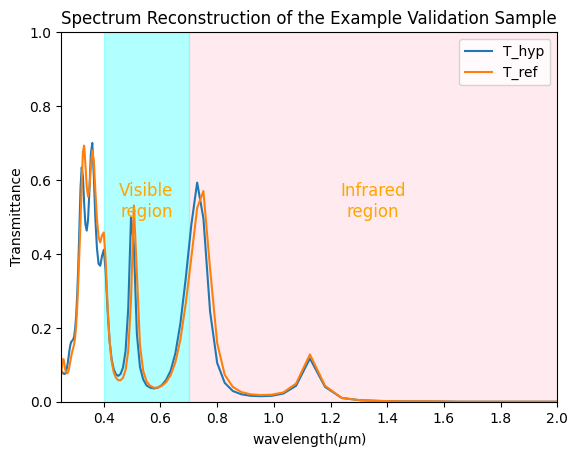

In [ ]:
import statistics

# 計算最大值和最小值（使用內建函數）
data = mses
max_value = max(data)
min_value = min(data)

# 計算平均值和標準差（使用 statistics 模組）
mean_value = statistics.mean(data)
stdev_value = statistics.stdev(data)

# 找到最接近平均值的索引
closest_index = min(range(len(data)), key=lambda i: abs(data[i] - mean_value))

# 輸出結果
print(len(data))
print(f"最大值: {max_value}")
print(f"最小值: {min_value}")
print(f"平均值: {mean_value}")
print(f"標準差: {stdev_value}")
print(f"最接近平均值的結構: {replace_materials(lines[2*closest_index].strip())}")
h_best = lines[2*closest_index].strip()
s_best = lines[2*closest_index + 1].strip()
s_best = list(map(float, s_best.split(",")))

show_spec_i(h_best, s_best)


30


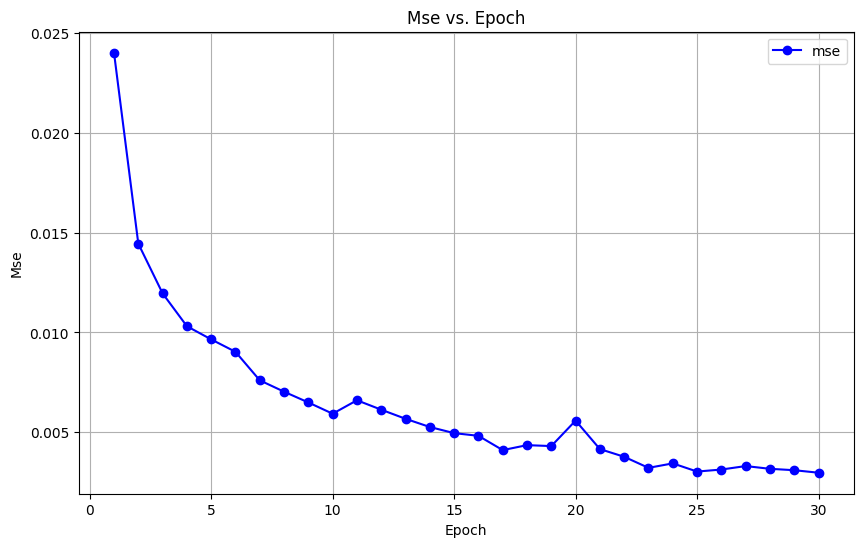

In [ ]:
print(len(Mses))
epoches = []
for i in range(30):
    epoches.append(i+1)

plt.figure(figsize=(10, 6))
plt.plot(epoches, Mses, label='mse', marker='o', linestyle='-', color='blue')
#plt.plot(epochs, val_losses, label='Validation Loss', marker='o', linestyle='--', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Mse')
plt.title('Mse vs. Epoch')
plt.legend()
plt.grid(True)
plt.show()



# Evaluate test data

### necessary functions


In [ ]:
from csv import DictReader
import numpy as np

wl_ag = []
n_ag = []
k_ag = []
with open('Ag.txt', 'r') as csv_file:
    reader = DictReader(csv_file, delimiter='\t', fieldnames=['wavelength', 'n', 'k'])
    for i, line in enumerate(reader):
        if i != 0:
            wl_ag.append(float(line['wavelength']))
            n_ag.append(float(line['n']))
            k_ag.append(float(line['k']))
wl_ag = np.array(wl_ag)
n_ag = np.array(n_ag)
k_ag = np.array(k_ag)
wll = wl_ag/1000

def n_al2o3(wl):#n = sqrt(1+X), wl:wavelength, ref:https://reurl.cc/g65Nqp, Sellmeier Eq
    nsq = 1 + 1.4313493*wl**2/(wl**2-0.0726631**2) + 0.65054713*wl**2/(wl**2-0.1193242**2) + 5.3414021*wl**2/(wl**2-18.028251**2)
    return np.sqrt(nsq)
def n_sio2(wl):
    nsq = 1 + 0.6961663*wl**2/(wl**2-0.0684043**2) + 0.4079426*wl**2/(wl**2-0.1162414**2) + 0.8974794*wl**2/(wl**2-9.896161**2)
    return np.sqrt(nsq)
def n_hfo2(wl):
    return 1.875 + 6.28e-3/(wl**2) + 5.8e-4/(wl**4)

def Tr_M(nl, dl, k): #nl is index array, dl is thickness array, k is the wave vector of incoming wave.
    #normal incidence
    TI = np.array([[(nl[0]+1)/(2*nl[0]), (nl[0]-1)/(2*nl[0])], [(nl[0]-1)/(2*nl[0]), (nl[0]+1)/(2*nl[0])]])
    TD = np.array([[np.exp(1j*nl[0]*k*dl[0]),0],[0,np.exp(-1j*nl[0]*k*dl[0])]])
    TM = TD @ TI#total matrix for air to the first layer TD*TI
    for i, n in enumerate(nl):
        if (i+1) < len(nl):
            n1 = n
            n2 = nl[i+1]
            d = dl[i+1]
            TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
            TD = np.array([[np.exp(1j*n2*k*d),0],[0,np.exp(-1j*n2*k*d)]])
            TM = (TD @ TI) @ TM
    n1 = nl[-1]
    n2 = 1
    TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
    TM = TI @ TM
    return -TM[1,0]/TM[1,1], TM[0,0] - TM[0,1]*TM[1,0]/TM[1,1]#r, t

In [ ]:
import re
import numpy as np

def get_nd(data):
    # 原始字串
    data_str = data  # "a_12.3,h_20.2,l_34.5,s_23.3"

    # 提取浮點數列表 d(um)
    d = [float(x)/1000 for x in re.findall(r"\d+\.\d+", data_str)]
    # 定義字母對應到數字的映射
    mapping = {'a': 4, 'h': 2, 'l': 3, 's': 1}

    # 提取標籤並映射到對應的數字 nl
    labels = [x.split('_')[0] for x in data_str.split(',')]
    nl = [mapping[label] for label in labels]

    # 顯示結果
    #print("d =", d)   # [12.3, 20.2, 34.5, 23.3]
    #print("nl =", nl) # [4, 2, 3, 1]
    return nl, d

def get_T(nl, dl):
    # Calculate transmission coefficients on GPU
    Tcl = []
    wll = wl_ag / 1000  # from Ag.txt

    for i, wl in enumerate(wll):
        nll = []
        for j in range(len(nl)):#get n(lambda) for each layer
            if nl[j] == 3:
                nll.append(n_al2o3(wl))
            elif nl[j] == 2:
                nll.append(n_hfo2(wl))
            elif nl[j] == 1:
                nll.append(n_sio2(wl))
            elif nl[j] == 4:
                nll.append(n_ag[i]+1j*k_ag[i])
        r, t = Tr_M(nll, dl, 2 * np.pi / wl)#coffs
        T = np.round(np.abs(t)**2 * 1000) / 1000  # Round to 3 decimal places
        Tcl.append(T)  # Move data back to CPU for saving and convert to scalar
    return Tcl


### 處理預測檔

In [ ]:
import re

# 定義正則表達式匹配格式
pattern = re.compile(r"^([ahsl]_\d{2,3}\.\d,)*[ahsl]_\d{2,3}\.\d$")

# 原始檔案名稱
infile = 'testmm6_prediction_6868.txt'
outfile = "testmm6_prediction_6868_md.txt"

# 讀取檔案
with open(infile, "r") as f:
    lines = f.readlines()

# 將符合格式的組 (h, s) 保留
filtered_lines = []
for i in range(0, len(lines), 2):  # 每兩行為一組
    h = lines[i].strip()  # 第一行是 h
    s = lines[i + 1].strip()  # 第二行是 s
    if pattern.match(h):  # 只檢查 h 是否符合格式
        filtered_lines.append(h + "\n")  # 保留 h
        filtered_lines.append(s + "\n")  # 保留對應的 s

# 覆寫檔案，僅寫入篩選後的內容
with open(outfile, "w") as f:
    f.writelines(filtered_lines)

print("不符合格式的數據組已刪除，符合格式的數據組已保留到文件中。")


不符合格式的數據組已刪除，符合格式的數據組已保留到文件中。


In [ ]:
import matplotlib.pyplot as plt
import torch
import math

def target_function(w_values, t_values):  # Loss = -FOM
    # 將 T 值和對應的 w 值轉換為 PyTorch 張量
    T_values = torch.tensor(t_values, dtype=torch.float32)
    w_values = torch.tensor(w_values, dtype=torch.float32)
    #print("w_values is: {}".format(w_values))
    #print("T_values is: {}".format(T_values))
    # 將波長轉換為角頻率 (rad/s)
    w_values = 6 * math.pi * 10**8 / w_values  # Convert to omega (rad/s)
    #print("w_values is: {}".format(w_values))
    # 篩選 w1 和 T1
    w1_mask = (w_values >= 2.69 * 10**9) & (w_values <= 4.96 * 10**9)
    w1 = w_values[w1_mask]
    T1 = T_values[w1_mask]

    # 篩選 w2 和 T2
    w2_mask = (w_values >= 9.42 * 10**8) & (w_values <= 9.42 * 10**9)
    w2 = w_values[w2_mask]
    T2 = T_values[w2_mask]
    #print("w1 is: {}".format(w1))
    #print("w2 is: {}".format(w2))
    #print("T1 is: {}".format(T1))
    #print("T2 is: {}".format(T2))
    # 計算積分
    I1 = torch.trapz(T1, w1)  # Numerator
    I2 = torch.trapz(T2, w2)  # Denominator
    #print("I1 is: {}".format(I1))
    #print("I2 is: {}".format(I2))
    # 計算 FOM 並返回負值作為損失
    FOM = I1 / I2
    #print("FOM is: {}".format(FOM.item()))

    return FOM  # Return negative FOM as the loss
    '''
    # 使用梯形法進行積分
    result = torch.trapz(T, w_values)
    print("離散 T 值的積分結果:", result)
    '''

def show_spec_i(hyp, Tr):
    nlh, dlh = get_nd(hyp)
    #nlr, dlr = get_nd(ref)
    Th = get_T(nlh, dlh)
    #Tr = get_T(nlr, dlr)
    plt.xlim(0.25,2)
    plt.ylim(0,1)
    plt.plot(wll, Th, label = 'T_hyp')
    plt.plot(wll, Tr, label = 'T_ref')
    # Highlighting regions with background color
    plt.axvspan(0.4, 0.7, color='aqua', alpha=0.3)  # Visible region
    plt.axvspan(0.7, 2, color='pink', alpha=0.3)    # Infrared region
    # Adding labels for regions
    plt.text(0.55, 0.5, "Visible\nregion", color="orange", fontsize=12, ha='center')
    plt.text(1.35, 0.5, "Infrared\nregion", color="orange", fontsize=12, ha='center')

    plt.xlabel("wavelength($\mu$m)")
    plt.ylabel("Transmittance")
    plt.title("Spectrum Reconstruction of the Example Test Sample")
    plt.legend()
    mse = np.mean((np.array(Tr) - np.array(Th)) ** 2)
    fom = target_function(wll, Th)

    # 顯示結果
    print(f"MSE: {mse:.4f}")
    print(f"FOM: {fom:.4f}")

def cal_i(hyp, Tr):
    nlh, dlh = get_nd(hyp)
    #nlr, dlr = get_nd(ref)
    Th = get_T(nlh, dlh)
    # 計算目標函數的值
    t_values = torch.tensor(Th)  # 將列表轉換為 PyTorch 張量
    w_values = torch.tensor(wll, dtype=torch.float32)  # 波長值張量
    fom = target_function(w_values, t_values)
    mse = np.mean((np.array(Tr) - np.array(Th)) ** 2)

    return mse, fom.item()

def replace_materials(input_str):
    # 定义替换规则
    replacements = {
        'h': 'HfO2',
        'a': 'Ag',
        'l': 'Al2O3',  # 如果需要处理 'l'，可以保留这条
        's': 'SiO2'
    }

    # 逐个替换
    for old, new in replacements.items():
        input_str = input_str.replace(old + '_', new + '_')

    return input_str

### main

In [ ]:
from tqdm import tqdm
infile = 'testmm6_prediction_6868_md.txt'

# 讀取檔案
with open(infile, "r") as f:
    lines = f.readlines()

h = lines[0].strip()  # 第一行是 h
s = lines[1].strip()  # 第二行是 s

print(h)
print(s)
decimal_list = list(map(float, s.split(",")))

print(decimal_list)

# 將符合格式的組 (h, s) 保留
mses = []
foms = []
for i in tqdm(range(0, len(lines), 2), desc="Calculating prediction"):
    h = lines[i].strip()  # 第一行是 h
    s = lines[i + 1].strip()  # 第二行是 s
    s = list(map(float, s.split(",")))
    mse, fom = cal_i(h, s)
    foms.append(fom)
    mses.append(mse)



a_19.9,s_83.0,h_92.6,s_24.6,a_19.1,s_119.2,h_46.4,s_32.6,l_64.5,s_58.8,l_61.2,s_115.1
0.051,0.047,0.047,0.047,0.045,0.044,0.044,0.046,0.053,0.064,0.074,0.079,0.076,0.070,0.065,0.063,0.063,0.065,0.068,0.071,0.073,0.075,0.077,0.078,0.078,0.077,0.074,0.071,0.069,0.068,0.068,0.069,0.071,0.074,0.076,0.077,0.077,0.077,0.078,0.080,0.083,0.087,0.092,0.099,0.108,0.118,0.131,0.144,0.160,0.183,0.213,0.252,0.288,0.326,0.353,0.336,0.295,0.245,0.206,0.185,0.182,0.200,0.244,0.326,0.458,0.602,0.650,0.585,0.495,0.441,0.428,0.450,0.510,0.599,0.667,0.647,0.560,0.463,0.380,0.314,0.255,0.200,0.150,0.109,0.081,0.063,0.052,0.045,0.042,0.040,0.039,0.038,0.037,0.035,0.031,0.028,0.025,0.024,0.024,0.027,0.032,0.043,0.069,0.142,0.384,0.528,0.218,0.100,0.055,0.032,0.019,0.011,0.006,0.004,0.002,0.002,0.001,0.001,0.001,0.001,0.001
[0.051, 0.047, 0.047, 0.047, 0.045, 0.044, 0.044, 0.046, 0.053, 0.064, 0.074, 0.079, 0.076, 0.07, 0.065, 0.063, 0.063, 0.065, 0.068, 0.071, 0.073, 0.075, 0.077, 0.078, 0.078, 0.077, 0.074,

Calculating prediction:   0%|          | 0/9733 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_10228\667072047.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  T_values = torch.tensor(t_values, dtype=torch.float32)
C:\Users\User\AppData\Local\Temp\ipykernel_10228\667072047.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w_values = torch.tensor(w_values, dtype=torch.float32)
Calculating prediction: 100%|██████████| 9733/9733 [02:26<00:00, 66.54it/s]


最大值: 0.06059547107438017
最小值: 9.99173553719008e-06
平均值: 0.0031157881009736834
標準差: 0.004406388963080041
最接近平均值的結構: HfO2_79.3,Al2O3_60.5,Ag_19.9,Al2O3_60.9,SiO2_27.3,HfO2_86.3,Ag_10.1,HfO2_84.1,SiO2_39.5,Ag_14.7,Al2O3_43.5,HfO2_95.5,SiO2_18.8,Al2O3_63.1
MSE: 0.0031
FOM: 0.4017


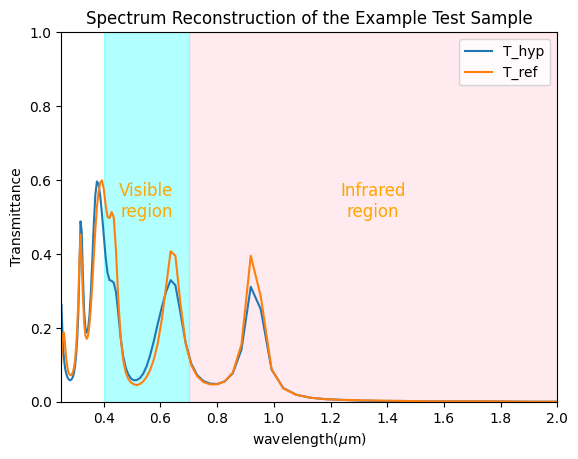

In [ ]:
import statistics

# 計算最大值和最小值（使用內建函數）
data = mses
max_value = max(data)
min_value = min(data)

# 計算平均值和標準差（使用 statistics 模組）
mean_value = statistics.mean(data)
stdev_value = statistics.stdev(data)

# 找到最接近平均值的索引
closest_index = min(range(len(data)), key=lambda i: abs(data[i] - mean_value))

# 輸出結果
print(f"最大值: {max_value}")
print(f"最小值: {min_value}")
print(f"平均值: {mean_value}")
print(f"標準差: {stdev_value}")
print(f"最接近平均值的結構: {replace_materials(lines[2*closest_index].strip())}")
h_best = lines[2*closest_index].strip()
s_best = lines[2*closest_index + 1].strip()
s_best = list(map(float, s_best.split(",")))

show_spec_i(h_best, s_best)


In [ ]:
# 計算最大值和最小值（使用內建函數）
data = mses
max_value = max(data)
min_value = min(data)

# 計算平均值和標準差（使用 statistics 模組）
mean_value = statistics.mean(data)
stdev_value = statistics.stdev(data)

max_index = data.index(max_value)

# 輸出結果
print(f"最大值: {max_value}")
print(f"最小值: {min_value}")
print(f"平均值: {mean_value}")
print(f"標準差: {stdev_value}")

最大值: 0.06059547107438017
最小值: 9.99173553719008e-06
平均值: 0.0031157881009736834
標準差: 0.004406388963080041


data size: 9999 
結構: a_18.6,h_19.5,s_27.8,h_20.3,s_27.8,a_19.9,s_34.8,h_31.1,s_33.6,a_19.9,h_48.6,l_20.1,a_10.2,l_30.3,h_40.9
MSE: 0.0013
FOM: 0.8561
結構: h_46.3,a_10.5,s_43.0,h_35.7,s_27.8,a_19.7,s_33.6,h_38.6,a_19.7,h_13.3,a_11.1,s_49.2,l_41.9,a_13.6,s_49.5
MSE: 0.0007
FOM: 0.8388
結構: a_10.1,h_35.1,s_40.0,a_17.7,h_49.7,l_32.0,a_10.1,s_34.8,h_48.6,s_49.7,l_37.5,h_35.2,a_19.7,h_48.0
MSE: 0.0027
FOM: 0.8322
結構: h_42.0,a_19.5,s_45.7,h_26.6,l_31.4,a_19.7,h_41.9,s_31.2,a_14.4,s_40.8,a_11.1,l_32.2
MSE: 0.0030
FOM: 0.8141
結構: a_15.9,s_49.2,h_49.7,a_19.9,s_26.1,h_49.6,a_16.6,l_14.1,h_49.2,s_41.7,a_13.9,s_14.9,h_38.6,l_21.7
MSE: 0.0038
FOM: 0.8141
結構: a_19.5,s_23.2,h_35.1,a_11.3,s_20.8,a_14.9,h_49.7,s_28.0,a_14.4,s_10.5,a_10.9,h_43.2,s_25.1,a_12.1,s_49.7
MSE: 0.0003
FOM: 0.8018
結構: a_18.6,s_49.7,h_32.9,a_18.3,s_33.6,a_17.7,h_44.3,s_28.6,a_19.8,s_48.6,h_19.8,s_10.5,h_38.7,l_14.1,h_31.0
MSE: 0.0015
FOM: 0.7958
結構: h_44.6,a_19.1,s_49.2,h_48.1,s_25.2,a_17.4,h_49.7,l_17.1,s_31.4,a_13.5,l_44.3,s_35.2

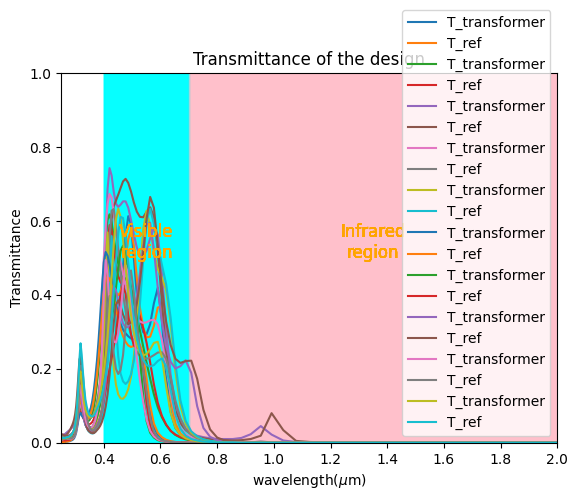

In [ ]:
data = foms
print("data size: {} ".format(len(data)))
top_10_indices = sorted(range(len(data)), key=lambda i: data[i], reverse = True)[0:10]
#top_10_indices = sorted(range(len(data)), key=lambda i: data[i], reverse=True)[:-10]
#last_10_indices = sorted(range(len(data)), key=lambda i: data[i])[-10:]
for i in range(len(top_10_indices)):
    max_index = top_10_indices[i]
    print(f"結構: {lines[2*max_index].strip() }")
    h_best = lines[2*max_index].strip()
    s_best = lines[2*max_index+1].strip()
    s_best = list(map(float, s_best.split(",")))

    show_spec_i(h_best, s_best)